<a href="https://colab.research.google.com/github/Thujaina/ECG-classification----Res-Net/blob/main/dice_loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.layers import Conv1D, MaxPooling1D, Dense, BatchNormalization, GlobalAveragePooling1D
from keras.layers import Add, Input
from keras.models import Model

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (87554, 188)


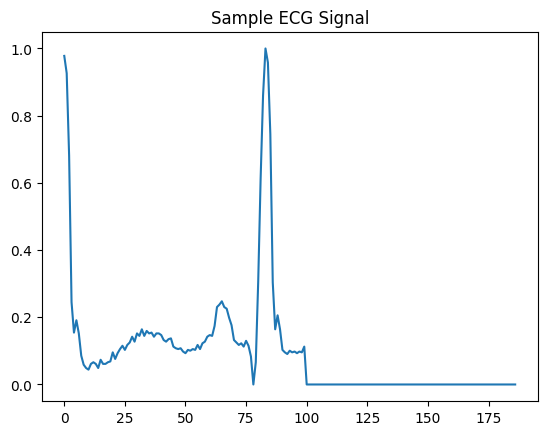

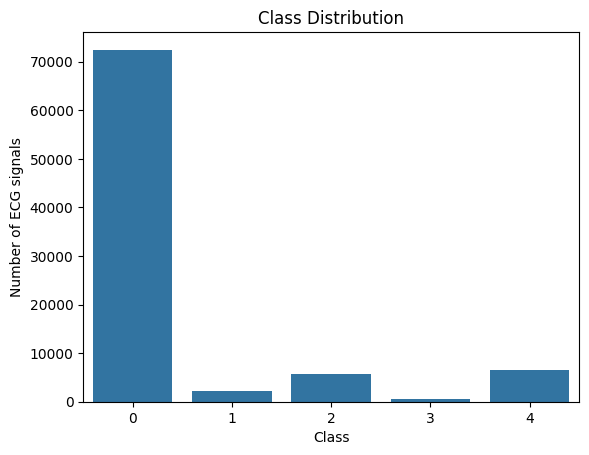

0
0


In [5]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")

plt.show()

print(train.isna().sum().sum())
print(test.isna().sum().sum())

In [6]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]


In [7]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [8]:
y_res_sparse = y_res
y_test_sparse = y_test

X_res = np.array(X_res).reshape(-1,187,1)
X_test = np.array(X_test).reshape(-1,187,1)

In [9]:
def resnet_block(x, filters, stride=1):

    shortcut = x

    x = Conv1D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)

    return x

def dice_loss(y_true, y_pred):

    y_true = tf.cast(y_true, tf.float32)

    smooth = 1e-6

    intersection = tf.reduce_sum(y_true * y_pred, axis=1)

    denominator = tf.reduce_sum(y_true, axis=1) + tf.reduce_sum(y_pred, axis=1)

    dice = (2.0 * intersection + smooth) / (denominator + smooth)

    return 1 - tf.reduce_mean(dice)

def resnet_ecg():

    inputs = Input(shape=(187,1))

    x = Conv1D(32,3,activation='relu')(inputs)
    x = BatchNormalization()(x)

    x = resnet_block(x,64)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,128)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,256)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128,activation='relu')(x)
    outputs = Dense(5,activation='softmax')(x)

    model = Model(inputs,outputs)

    model.compile(
    optimizer='adam',
    loss=dice_loss,
    metrics=['accuracy']
)

    return model



In [10]:
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res, y_res_sparse)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]

    y_tr = tf.keras.utils.to_categorical(y_res_sparse.iloc[train_idx], 5)
    y_va = tf.keras.utils.to_categorical(y_res_sparse.iloc[val_idx], 5)

    model = resnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=1)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 55s 10ms/step - accuracy: 0.9002 - loss: 0.1031
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 67s 9ms/step - accuracy: 0.9338 - loss: 0.0669
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.9461 - loss: 0.0543
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9514 - loss: 0.0488
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9578 - loss: 0.0424
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9338 - loss: 0.0665
Fold 1 Accuracy: 0.9338

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 51s 11ms/step - accuracy: 0.8951 - loss: 0.1080
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.9337 - loss: 0.0670
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9453 - loss: 0.0551
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.9525 - loss: 0.0478
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9575 - loss: 0.0427


In [11]:
from tensorflow.keras.utils import to_categorical
# Reshape full SMOTE-resampled data for training
X_res_reshaped = np.array(X_res).reshape(-1, 187, 1)
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

# Split for validation (optional, you can use full train data too)
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res_reshaped, y_res_cat, test_size=0.2, random_state=42
)

In [12]:
# Create the ResNet model
model = resnet_ecg()

# Train the model
history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 68s 13ms/step - accuracy: 0.9025 - loss: 0.0998 - val_accuracy: 0.9227 - val_loss: 0.0790
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.9378 - loss: 0.0628 - val_accuracy: 0.9311 - val_loss: 0.0695
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - accuracy: 0.9471 - loss: 0.0531 - val_accuracy: 0.8687 - val_loss: 0.1314
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.9591 - loss: 0.0410 - val_accuracy: 0.4658 - val_loss: 0.5342
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.9661 - loss: 0.0340 - val_accuracy: 0.9145 - val_loss: 0.0859
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.9705 - loss: 0.0295 - val_accuracy: 0.9585 - val_loss: 0.0417
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.9731 - loss: 0.0271 - val_accuracy: 0.9616 - val_loss: 0.0385
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - accuracy: 0.9748 -

In [13]:
# Evaluate on validation set
y_val_pred = np.argmax(model.predict(X_val_final), axis=1)
y_val_true = np.argmax(y_val_final, axis=1)
mcc_val = matthews_corrcoef(y_val_true, y_val_pred)
print("Validation MCC:", mcc_val)

2265/2265 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
Validation MCC: 0.9432538983670591


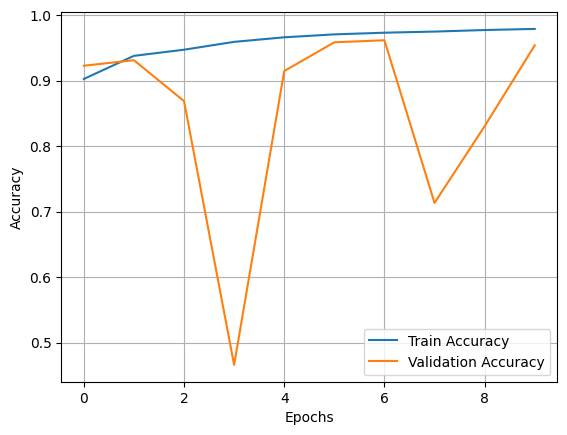

In [14]:
# Plot training/validation accuracy
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

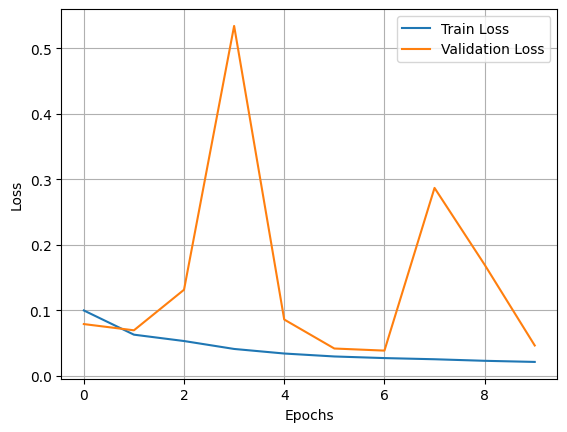

In [15]:
# Plot training/validation loss
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [16]:
# Final training & validation metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

Final Training Accuracy: 0.9789
Final Validation Accuracy: 0.9538
Final Training Loss: 0.0212
Final Validation Loss: 0.0463


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Test set classification report
y_test_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_test_pred))

Test Loss: 0.4169
Test Accuracy: 0.9880
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     72471
         1.0       0.78      0.87      0.82      2223
         2.0       0.99      0.99      0.99      5788
         3.0       0.99      0.88      0.94       641
         4.0       1.00      1.00      1.00      6431

    accuracy                           0.99     87554
   macro avg       0.95      0.95      0.95     87554
weighted avg       0.99      0.99      0.99     87554



2737/2737 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step


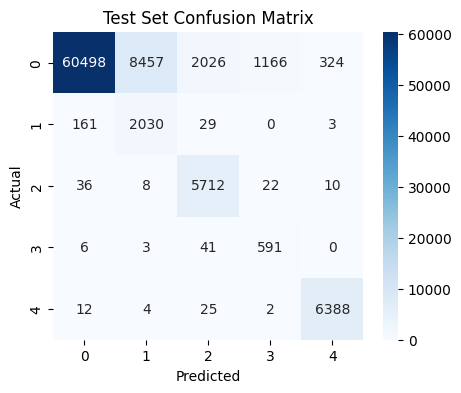

In [19]:
# Test set predictions
y_test_pred = np.argmax(model.predict(X_test), axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Set Confusion Matrix")
plt.show()